#### ① 导入库和加载数据

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 下载 MNIST 数据
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 归一化到 [0,1] 并增加通道维度
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print('训练集形状：', X_train.shape)
print('测试集形状：', X_test.shape)

训练集形状： (60000, 28, 28, 1)
测试集形状： (10000, 28, 28, 1)


#### ② 构建 CNN 模型

In [17]:
def create_lenet_style_cnn():
    model = models.Sequential([
        # 第一个卷积块
        layers.Conv2D(6, kernel_size = 5, activation = 'relu', input_shape = (28, 28, 1)),
        layers.MaxPooling2D(pool_size = 2, strides = 2),

        # 第二个卷积块
        layers.Conv2D(16, kernel_size = 5, activation = 'relu'),
        layers.MaxPooling2D(pool_size = 2, strides = 2),

        # 全连接层
        layers.Flatten(),
        layers.Dense(120, activation = 'relu'),
        layers.Dense(84, activation = 'relu'),
        layers.Dense(10, activation = 'softmax')
    ])
    return model

model = create_lenet_style_cnn()
model.summary() # 打印网络结构

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

#### ③ 编译和训练

In [18]:
model.compile(optimizer = 'adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics = ['accuracy'])

history = model.fit(X_train, y_train, 
                    batch_size = 64, 
                    epochs = 10, 
                    validation_split = 0.1) # 自动化分 10% 作为验证集

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9191 - loss: 0.2672 - val_accuracy: 0.9773 - val_loss: 0.0780
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9763 - loss: 0.0780 - val_accuracy: 0.9818 - val_loss: 0.0616
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9820 - loss: 0.0571 - val_accuracy: 0.9857 - val_loss: 0.0497
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9859 - loss: 0.0459 - val_accuracy: 0.9867 - val_loss: 0.0470
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9878 - loss: 0.0373 - val_accuracy: 0.9858 - val_loss: 0.0517
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9894 - loss: 0.0317 - val_accuracy: 0.9895 - val_loss: 0.0431
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9908 - loss: 0.0276 - val_accuracy: 0.9888 - val_loss: 0.0419
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9927 - loss: 0.0229 - val_accuracy: 0.

#### ④ 评估与可视化训练曲线

测试准确率: 0.9883


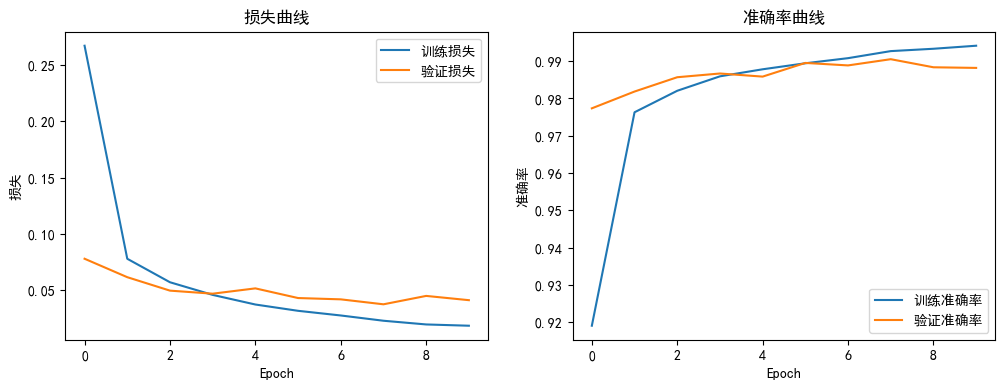

In [19]:
# 测试集评估
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"测试准确率: {test_acc:.4f}")

# 绘制训练/验证损失和准确率
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(history.history['loss'], label='训练损失')
ax1.plot(history.history['val_loss'], label='验证损失')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('损失')
ax1.legend()
ax1.set_title('损失曲线')

ax2.plot(history.history['accuracy'], label='训练准确率')
ax2.plot(history.history['val_accuracy'], label='验证准确率')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率')
ax2.legend()
ax2.set_title('准确率曲线')

plt.show()


#### ⑤ 预测与真实对比图

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


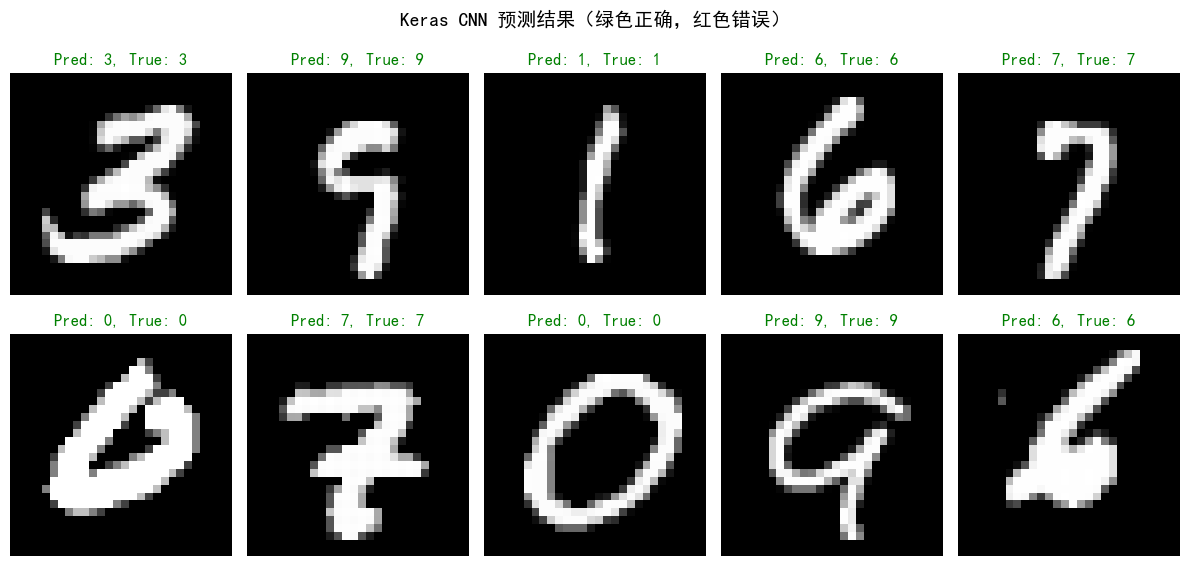

In [20]:
# 随机取 10 个测试样本展示
n_samples = 10
indices = np.random.choice(len(X_test), n_samples, replace=False)
X_sample = X_test[indices]
y_true = y_test[indices]

# 模型预测
predictions = model.predict(X_sample)
y_pred = np.argmax(predictions, axis=1)

# 绘图
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(n_samples):
    axes[i].imshow(X_sample[i, :, :, 0], cmap='gray')
    title = f"Pred: {y_pred[i]}, True: {y_true[i]}"
    axes[i].set_title(title, fontsize=12,
                      color='green' if y_pred[i] == y_true[i] else 'red')
    axes[i].axis('off')

plt.suptitle("Keras CNN 预测结果（绿色正确，红色错误）", fontsize=14)
plt.tight_layout()
plt.show()